Recruitment Agency Workflow 


In [134]:
!pip install langchain langchain_core langchain_community langgraph langchain_genai

ERROR: Could not find a version that satisfies the requirement langchain_genai (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for langchain_genai


In [135]:
from dotenv import load_dotenv
import os 

load_dotenv()

api_key = os.getenv("GOOGLE_API_KEY")

In [136]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model = "gemini-1.5-flash-latest",
    temperature = 0.7
)

In [137]:
from typing_extensions import TypedDict 

class State(TypedDict):
    application:str
    experience_level: str 
    skill_match: str 
    response: str 

In [138]:
from langgraph.graph import StateGraph, START, END 

workflow = StateGraph(State)

In [139]:
from langchain_core.prompts import ChatPromptTemplate

In [140]:
from langchain_core.prompts import ChatPromptTemplate

# 1. Categorize Experience
def categorize_experience(state: State) -> State:
    print("\nCategorizing the experience level of candidate:")

    prompt = ChatPromptTemplate.from_template(
        "Based on the following job application, categorize the candidate as "
        "'Entry-level', 'Mid-level', or 'Senior-level'. "
        "Respond ONLY with one of these three options.\n"
        "Application: {application}"
    )

    chain = prompt | llm
    experience_level = chain.invoke({
        "application": state["application"]
    }).content.strip()

    print(f"Experience Level: {experience_level}")

    return {"experience_level": experience_level}


# 2. Assess Skillset
def assess_skillset(state: State) -> State:
    print("\nAssessing the skillset of candidate:")

    prompt = ChatPromptTemplate.from_template(
        "Based on the job application for a Python Developer, assess whether the candidate's "
        "skills match the job requirements. "
        "Respond ONLY with 'Match' or 'No Match'.\n"
        "Application: {application}"
    )

    chain = prompt | llm
    skill_match = chain.invoke({
        "application": state["application"]
    }).content.strip()

    print(f"Skill Match: {skill_match}")

    return {"skill_match": skill_match}


# 3. Schedule HR Interview
def schedule_hr_interview(state: State) -> State:
    print("\nScheduling the interview:")
    return {
        "response": "Candidate has been shortlisted for an HR interview."
    }


# 4. Escalate to Recruiter
def escalate_to_recruiter(state: State) -> State:
    print("\nEscalating to recruiter:")
    return {
        "response": "Candidate has senior-level experience but does not match job skills."
    }


# 5. Reject Application
def reject_application(state: State) -> State:
    print("\nSending rejection email:")
    return {
        "response": "Candidate does not meet the job requirements and has been rejected."
    }

In [141]:
workflow.add_node("categorize_experience",categorize_experience)
workflow.add_node("assess_skillset",assess_skillset)
workflow.add_node("schedule_hr_interview",schedule_hr_interview)
workflow.add_node("escalate_to_recruiter",escalate_to_recruiter)
workflow.add_node("reject_application",reject_application)

In [142]:
def route_app(state:State) -> str:
    if(state["skill_match"]=="Match"):
        return "schedule_hr_interview"
    elif(state["experience_level"] == "Senior-level"):
        return "escalate_to_recruiter"
    else:
        return "reject_application"

In [143]:
from langgraph.graph import START, END

# Start of workflow
workflow.add_edge(START, "categorize_experience")

# Linear flow
workflow.add_edge("categorize_experience", "assess_skillset")

# Conditional routing
workflow.add_conditional_edges(
    "assess_skillset",
    route_app,
    {
        "schedule_hr_interview": "schedule_hr_interview",
        "escalate_to_recruiter": "escalate_to_recruiter",
        "reject_application": "reject_application"
    }
)

# End connections
workflow.add_edge("schedule_hr_interview", END)
workflow.add_edge("escalate_to_recruiter", END)
workflow.add_edge("reject_application", END)

In [144]:
workflow.add_edge(START, "categorize_experience")
workflow.add_edge("assess_skillset",END)
workflow.add_edge("escalate_to_recruiter",END)
workflow.add_edge("reject_application",END)
workflow.add_edge("schedule_hr_interview",END)



In [145]:
app = workflow.compile()

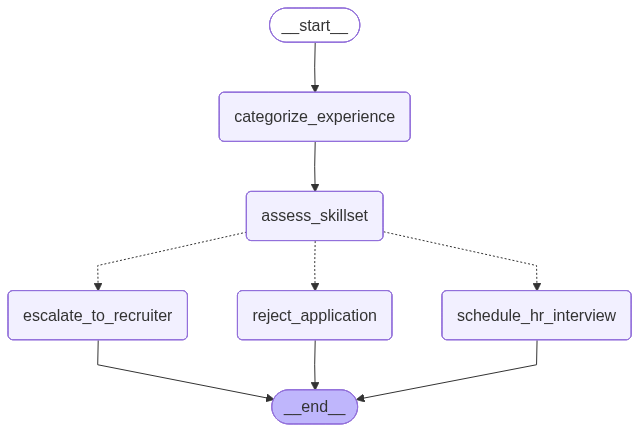

In [146]:
from IPython.display import Image,display 

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [147]:
def run_candidate_screening(application: str):
    if not application:
        raise ValueError("Application text cannot be empty")

    results = app.invoke({"application": application})

    return {
        "experience_level": results.get("experience_level"),
        "skill_match": results.get("skill_match"),
        "response": results.get("response")
    }

In [148]:
application_text = "I have 10 years of experience in software engineering with expertise in JAVA"
results = run_candidate_screening(application_text)
print("\n\nComputed Results :")
print(f"Application: {application_text}")
print(f"Experience Level: {results['experience_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Response: {results['response']}")


Categorizing the experience level of candidate:


Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised NotFound: 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods..
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 4.0 seconds as it raised NotFound: 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods..
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 8.0 seconds as it raised NotFound: 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods..
Retrying langchain_google_genai.chat_mod

NotFound: 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.

In [ ]:
application_text = "I have 1 year of experience in software engineering with expertise in JAVA"
results = run_candidate_screening(application_text)
print("\n\nComputed Results : ")
print(f"Application: {application_text}")
print(f"Experience Level: {results['experience_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Response: {results['response']}")



 Categorizing the experience level of candidate: 


NameError: name 'llm' is not defined

In [ ]:
application_text = "I have experience in software engineering with expertise in Python"
results = run_candidate_screening(application_text)
print("\n\nComputed Results :")
print(f"Application: {application_text}")
print(f"Experience Level: {results['experience_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Response: {results['response']}")

In [ ]:
application_text = "I have 5 years of experience in software engineering with expertise in C++"
results = run_candidate_screening(application_text)
print("\n\nComputed Results :")
print(f"Application: {application_text}")
print(f"Experience Level: {results['experience_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Response: {results['response']}")